# Detecció d'opinions (pràctica 2.a)
### Recursos

- Movie Reviews Corpus

### Enunciat

- Implementeu un detector d'opinions positives o negatives amb alguns algoritmes d'aprenentatge supervisat de l'sklearn # perceptro, svm i arbres (3 models diferents)

- Utilitzeu com a dades el Movie Reviews Corpus de l'NLTK

- Dissenyeu i apliqueu un protocol de validació

- Utilitzeu el preprocés que cregueu més convenient: eliminació d'stop words, signes de puntuació... (reduir la dimensionalitat del vocabulari (amb lemes de diccionary o symsets))

- Utilitzeu el CountVectorizer per representar la informació

- Doneu la precisió (accuracy) i les matrius de confusió

- Analitzeu els resultats (Analitzar les frases que fallen)

num_features = 5000 <-- fixar mida de diccionari

## NLTK’s Movie Reviews Corpus

### Polarity corpus:

- 1000 exemples positius i 1000 negatius

### Requeriments:

In [ ]:
import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import sentiwordnet as swn
from nltk.wsd import lesk
from nltk.tokenize import word_tokenize
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('sentiwordnet')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Ús:

In [3]:
mr.fileids('pos')[:2]

['pos/cv000_29590.txt', 'pos/cv001_18431.txt']

In [4]:
len(mr.fileids('neg'))

1000

In [5]:
mr.words()

['plot', ':', 'two', 'teen', 'couples', 'go', 'to', ...]

In [6]:
mr.raw(mr.fileids('pos')[:2][0]).split("\n")[:10]

["films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . ",
 "for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . ",
 'to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . ',
 'the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . ',
 "in other words , don't dismiss this film because of its source . ",
 "if you can get past the whole comic book thing , you might find another stumbling block in from hell's directors , albert and allen hughes . ",
 "getting the hughes brothers to di

## CountVectorizer de l'sklearn

Codificador bag of words (TF-IDF)

### Exemple:

This is the first document.
This document is the second document.
And this is the third one.
Is this the first document?

### Matriu resultant:

0 1 1 1 0 0 1 0 1
0 2 0 1 0 1 1 0 1
1 0 0 1 1 0 1 1 1
0 1 1 1 0 0 1 0 1

### Diccionari:

index	word  
0:      and  
1:    document  
2:     first  
3:      is  
4:     one  
5:    second  
6:     the  
7:    third  
8:    this

### Referència:

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [ ]:
with open("stop_words_english.txt", 'r', encoding='utf-8') as file:
        stop_words = file.read().splitlines()

#for s in stop_words:
#    print(s)

the


In [203]:
import nltk
from nltk.corpus import movie_reviews

nltk.download('movie_reviews')

documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
X = [doc[0] for doc in documents]
y = [doc[1] for doc in documents]

for i in range(len(X)):
    cleaned_text = re.sub(r'\d+', '', X[i])  # Eliminar els números
    cleaned_text = re.sub(r'_+', '', cleaned_text)  # Eliminar els _
    cleaned_text = re.sub(r',+', '', cleaned_text)  # Eliminar els ,
    cleaned_text = cleaned_text.replace('.', '')  # Eliminar els .
    cleaned_text = re.sub(r'\bthe\b', '', cleaned_text, flags=re.IGNORECASE)  # Eliminar els the mayuscules o minuscules
    cleaned_text = re.sub(r'\band\b', '', cleaned_text, flags=re.IGNORECASE)  # Eliminar els and mayuscules o minuscules
    #for s in stop_words:
    #    cleaned_text = re.sub(r'\b' + re.escape(s) + r'\b', '', cleaned_text)  # Eliminar els stop_words
    cleaned_text = re.sub(r'[ \t]+', ' ', cleaned_text) # Canviar (1 o més)espais i tabulacions per 1 espai
    X[i] = cleaned_text

# Dividir en entrenament i test (80% entrenament, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


SVM Performance:
              precision    recall  f1-score   support

         neg       0.80      0.81      0.81       199
         pos       0.81      0.80      0.80       201

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.80       400
weighted avg       0.81      0.81      0.80       400



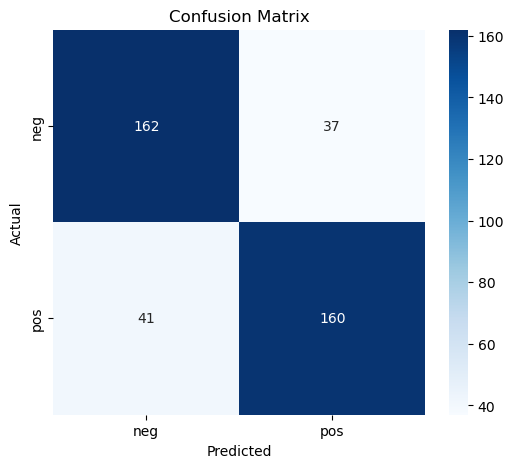

In [204]:
vectorizer = CountVectorizer(max_features=5000)
X_train_features = vectorizer.fit_transform(X_train)

svm = SVC(kernel='linear')
svm.fit(X_train_features, y_train)

X_test_features = vectorizer.transform(X_test)
y_pred = svm.predict(X_test_features)

accuracy_svm = accuracy_score(y_test, y_pred)

print("SVM Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

SVM Performance:
              precision    recall  f1-score   support

         neg       0.80      0.82      0.81       199
         pos       0.82      0.80      0.81       201

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



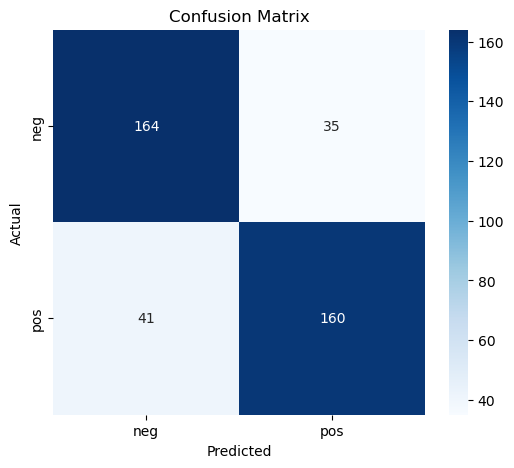

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"0.75_(1, 2)_10_rbf","{'countvectorizer__max_df': 0.75, 'countvector...",1,0.825000,0.026443
"1.0_(1, 1)_10_rbf","{'countvectorizer__max_df': 1.0, 'countvectori...",2,0.822500,0.019101
"1.0_(1, 2)_10_rbf","{'countvectorizer__max_df': 1.0, 'countvectori...",3,0.821875,0.022097
"0.75_(1, 1)_0.1_linear","{'countvectorizer__max_df': 0.75, 'countvector...",4,0.819375,0.024953
"0.75_(1, 1)_10_linear","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.818750,0.025996
"0.75_(1, 1)_1_linear","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.818750,0.025996
"0.75_(1, 2)_0.1_linear","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.818750,0.013550
"0.75_(1, 2)_10_linear","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.818750,0.013550
"0.75_(1, 2)_1_linear","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.818750,0.013550


In [205]:
pipeline = make_pipeline(CountVectorizer(max_features=5000), SVC())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2)],
    'countvectorizer__max_df': [0.75, 1.0],
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_svm.fit(X_train, y_train)

y_pred = gs_svm.predict(X_test)

print("SVM Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_svm.classes_, yticklabels=gs_svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_svm.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

Perceptron Performance:
              precision    recall  f1-score   support

         neg       0.83      0.83      0.83       199
         pos       0.84      0.84      0.84       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



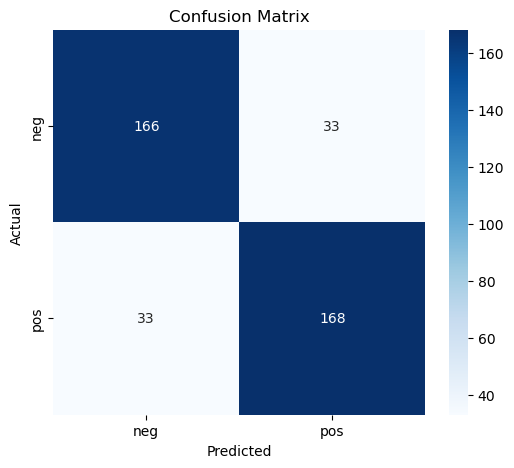

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"1.0_1_(1, 2)_0.0001_1000_l1","{'countvectorizer__max_df': 1.0, 'countvectori...",1,0.82000,0.037113
"1.0_1_(1, 2)_0.0001_2000_l1","{'countvectorizer__max_df': 1.0, 'countvectori...",1,0.82000,0.037113
"1.0_5_(1, 2)_0.01_1000_None","{'countvectorizer__max_df': 1.0, 'countvectori...",3,0.81375,0.022845
"1.0_5_(1, 2)_0.0001_1000_None","{'countvectorizer__max_df': 1.0, 'countvectori...",3,0.81375,0.022845
"1.0_5_(1, 2)_0.01_2000_None","{'countvectorizer__max_df': 1.0, 'countvectori...",3,0.81375,0.022845
...,...,...,...,...
"0.75_1_(1, 2)_0.01_1000_l2","{'countvectorizer__max_df': 0.75, 'countvector...",139,0.55375,0.053121
"1.0_1_(1, 1)_0.01_1000_l2","{'countvectorizer__max_df': 1.0, 'countvectori...",141,0.51500,0.015233
"1.0_1_(1, 1)_0.01_2000_l2","{'countvectorizer__max_df': 1.0, 'countvectori...",141,0.51500,0.015233


In [206]:
pipeline = make_pipeline(CountVectorizer(max_features=5000), Perceptron())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2)],
    'countvectorizer__max_df': [0.75, 1.0],
    'countvectorizer__min_df': [1, 5],
    'perceptron__penalty': [None, 'l2', 'l1'],
    'perceptron__alpha': [0.0001, 0.001, 0.01],
    'perceptron__max_iter': [1000, 2000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_per = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_per.fit(X_train, y_train)

y_pred = gs_per.predict(X_test)

print("Perceptron Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_per.classes_, yticklabels=gs_per.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_per.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       199
           1       0.86      0.81      0.83       201

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



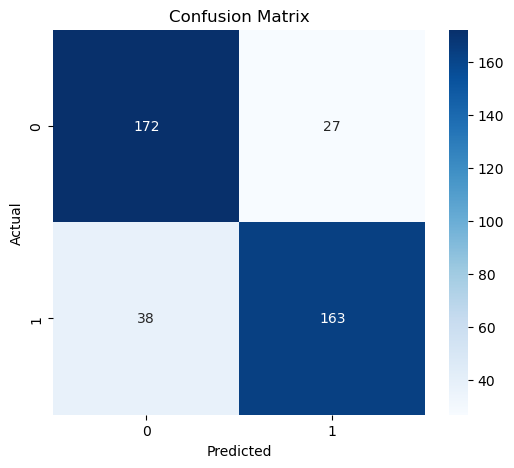

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"1.0_(1, 2)_0.1_3_200_1.0","{'countvectorizer__max_df': 1.0, 'countvectori...",1,0.836875,0.018049
"0.75_(1, 2)_0.3_3_200_0.8","{'countvectorizer__max_df': 0.75, 'countvector...",2,0.828750,0.018371
"0.75_(1, 2)_0.1_6_200_0.8","{'countvectorizer__max_df': 0.75, 'countvector...",3,0.828125,0.014389
"1.0_(1, 1)_0.1_3_200_0.8","{'countvectorizer__max_df': 1.0, 'countvectori...",4,0.825625,0.015104
"0.75_(1, 2)_0.1_3_200_0.8","{'countvectorizer__max_df': 0.75, 'countvector...",5,0.825000,0.019060
...,...,...,...,...
"1.0_(1, 1)_0.1_6_100_1.0","{'countvectorizer__max_df': 1.0, 'countvectori...",60,0.795625,0.010193
"1.0_(1, 1)_0.3_6_100_1.0","{'countvectorizer__max_df': 1.0, 'countvectori...",60,0.795625,0.017071
"0.75_(1, 1)_0.1_3_100_0.8","{'countvectorizer__max_df': 0.75, 'countvector...",62,0.794375,0.027698


In [207]:
pipeline = make_pipeline(CountVectorizer(max_features=5000), XGBClassifier(eval_metric='logloss'))

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2)],
    'countvectorizer__max_df': [0.75, 1.0],
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__max_depth': [3, 6],
    'xgbclassifier__learning_rate': [0.1, 0.3],
    'xgbclassifier__subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
gs_xgb.fit(X_train, y_train_encoded)

y_test_encoded = le.fit_transform(y_test)
y_pred = gs_xgb.predict(X_test)

print("XGBoost Performance:")
print(classification_report(y_test_encoded, y_pred))

cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_xgb.classes_, yticklabels=gs_xgb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_xgb.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(max_features=5000)
vectorizer.fit_transform(X_train)
for i in vectorizer.get_feature_names_out():
    print(i, end=" ")

aaron abandon abandoned abilities ability aboard absence absent absolute absolutely absurd abuse abyss academy accent accents accept acceptable acceptance accepted accepts accident accidentally acclaimed accompanied accomplish accomplished accomplishment account accurate accurately accused ace achieve achieved achievement achieves acid acted acting action actions activities actor actors actress actresses acts actual ad adam adams adaptation adapted add addict addiction adding addition adds adequate admirable admirably admire admired admission admit admits admittedly adolescent adorable ads adult adults advance advanced advantage adventure adventures advice affair affairs affect affection affleck aforementioned afraid africa african age aged agent agents ages aggressive aging agree agrees aid aimed air airplane airport al alan alas albeit albert alcohol alcoholic alda alec alex alexander alfred ali alice alicia alien aliens alike alive allen allowed allowing ally alternate alternative a

In [95]:
pattern = re.compile(r'iii')
for i in range(len(X)):
    for j in pattern.finditer(X[i]):
        print(X[i][j.start() - 20:j.end() + 20])

ff ( brendan sexton iii ) , suffers from ni
s clarence williams iii as the general's ai
 to start world war iii ? 
cia analyst jack
 . 
i love superman iii . 
i know it's hate
even rival superman iii in terms of quality
 of decades ago . 
riiiiight . 
y'know , th
liked lethal weapon iii , even while admitt
hat episodes ii and iii have something of s
to join king louis xiii's elite guard , the
, clarence williams iii . 
rated r . 
the l
arence williams the iii as the arrogant , l
ment in " godfather iii " where michael say
 the godfather part iii and superman iii-wo
rt iii and superman iii-woefully out of syn
e in drunken master iii ! ) , comedic chaos
 to the future part iii ; if your answer is
r were in star trek iii . 
these are far wo
mours of highlander iii : the wizard . 

 the godfather part iii , sofia coppola pro
why " jurassic park iii " is better than it
t , " jurassic park iii " simply sticks its
ot more . 
it's nothiiiiiinggggggggggg ! ! 
more . 
it's nothiiiiiinggggggggggg

# Detecció d'opinions (pràctica 2.b)

### Enunciat

- Implementeu un detector d'opinions positives o negatives no supervisat

    1. Apliqueu l'UKB per obtenir els synsets de les paraules (nltk lesk)
    2. Obtingueu els valors SentiWordnet de cada synset

- Utilitzeu com a dades el/els conjunts de test que hagueu utilitzat a la pràctica 2.a

- Penseu en com podeu combinar aquests valors per obtenir un resultat

- Penseu que fareu si el synset no hi és a SentiWordnet

- Penseu quines categories utilitzareu:

    - només adjectius
    - noms, adjectius i adverbis
    - noms, adjectius, verbs i adverbis (com a minim fer aquestes combinacions)

- Analitzeu els resultats i compareu-los amb els de la part supervisada

    - Desambiguació de 10 frases amb lesk and UKB i comparar la desambiguació que han fet -----> (Com que la diferencia no es tan gran farem servir lesk)

svm, perceptro, preprocessat | noms, adjectius i adverbis i pensar només adjectius

In [102]:
# UKB
from textserver import TextServer
# Lesk
from nltk.corpus import wordnet as wn
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
wnl = nltk.stem.WordNetLemmatizer()
def lemmatize(p):
  d = {'NN': 'n', 'NNS': 'n', 
       'JJ': 'a', 'JJR': 'a', 'JJS': 'a', 
       'VB': 'v', 'VBD': 'v', 'VBG': 'v', 'VBN': 'v', 'VBP': 'v', 'VBZ': 'v', 
       'RB': 'r', 'RBR': 'r', 'RBS': 'r'}
  if p[1] in d:
    return wnl.lemmatize(p[0], pos=d[p[1]]), d[p[1]]
  return p[0], None

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
frase = mr.raw(mr.fileids('pos')[:2][0]).split("\n")[0] # Lesk
words = nltk.word_tokenize(frase, language='english')
tags = nltk.pos_tag(words)
resultat_lesk = []
for pair in tags:
    lem = lemmatize(pair)
    if lem[1] != None:
        synset = nltk.wsd.lesk(frase, *lem)
        if synset:
            resultat_lesk.append((pair[0],synset.name(), synset.definition()))
        else:
            resultat_lesk.append((pair[0],"", ""))

[('films', 'movie.n.01', 'a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement'), ('adapted', 'adapt.v.01', 'make fit for, or change to suit a new purpose'), ('comic', 'comic.a.02', 'of or relating to or characteristic of comedy'), ('books', 'script.n.01', 'a written version of a play or other dramatic composition; used in preparing for a performance'), ('have', 'induce.v.02', 'cause to do; cause to act in a specified manner'), ('had', 'induce.v.02', 'cause to do; cause to act in a specified manner'), ('plenty', 'plenty.n.01', 'a full supply'), ('success', 'success.n.03', 'a state of prosperity or fame'), ("'re", '', ''), ('superheroes', '', ''), ('batman', 'batman.n.01', 'an orderly assigned to serve a British military officer'), ('superman', 'demigod.n.01', 'a person with great powers and abilities'), ('spawn', 'spawn.n.01', 'the mass of eggs deposited by fish or amphibians or molluscs'), ('geared', 'gear.v.01', 'set

In [172]:
frase = mr.raw(mr.fileids('pos')[:2][0]).split("\n")[0] # UKB
ts = TextServer('davidvazquez', 'c4tSX16B!', 'senses') 
synset_table = ts.senses(frase)
resultat_ukb = []
for frase_synset in synset_table:
    for synset in frase_synset:
        if synset[4] != 'N/A':
            syn = wn.synset_from_pos_and_offset(synset[4][-1], int(synset[4][:-2]))
            resultat_ukb.append((synset[0],syn.name(), syn.definition()))
        else:
            resultat_lesk.append((synset[0],"", ""))

In [179]:
print(frase)

def search_equal(res_search, search_term, i):
    while i < len(res_search):
        if search_term == res_search[i][0]:
            return True
        i += 1
    return False

i = 0
j = 0
while i < len(resultat_lesk):
    # Print lesk synset
    k = j
    print(f"lesk: {resultat_lesk[i][0]} {resultat_lesk[i][1]} {resultat_lesk[i][2]}", end=" " if k < len(resultat_ukb) else "\n")
    printed = False
    while k < len(resultat_ukb):
        # Check if words match
        if resultat_lesk[i][0] == resultat_ukb[k][0]:
            printed = True
            # Print matched synsets side by side
            print(f"{' ' * (150 - len(resultat_lesk[i][0]) - len(resultat_lesk[i][1]) - len(resultat_lesk[i][2]))} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
            k += 1
            break
        else:
            if search_equal(resultat_lesk, resultat_ukb[k][0], i):
                if not printed:
                    print()
                break
            printed = True
            print(f"\n{' '*159} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
            k += 1
    
    # Move the index for lesk and ukb to next unmatched synset
    j = k
    i += 1

# Print remaining ukb synsets if they don’t match any from lesk
while j < len(resultat_ukb):
    print(f"{' ' * 150} ukb: {resultat_ukb[j][0]} {resultat_ukb[j][1]} {resultat_ukb[j][2]}")
    j += 1

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
lesk: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement                 ukb: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement
lesk: adapted adapt.v.01 make fit for, or change to suit a new purpose                                                                                          ukb: adapted adapt.v.01 make fit for, or change to suit a new purpose
lesk: comic comic.a.02 of or relating to or characteristic of comedy                                                                                            ukb: comic amusing.s.02 arousing or prov

lesk=ukb -> success, spawn, world, never, hell
lesk -> comic, plenty(f), superman, comic
ukb -> books, kids, ghost(f), is(f), been, book
lesk>ukb -> have, had
ukb>lesk ->
casper -> mal(lesk)
there -> mal(ukb)

In [210]:
# Cargar les ressenyes de movie_reviews
reviews = [(list(movie_reviews.words(fileid)), category)
           for fileid in movie_reviews.fileids()
           for category in [fileid.split('/')[0]]]

def get_sentiment_from_synset(synset):
    if synset:
        senti_synset = swn.senti_synset(synset.name())
        return senti_synset.pos_score() - senti_synset.neg_score()
    return 0.0  # Si no trobem cap synset, retornem un sentiment neutral

def analyze_review_sentiment(review, accepted = ["n", "v", "r", "a"]):
    sentiment_score = 0.0
    
    words = nltk.word_tokenize(review, language='english')
    tags = nltk.pos_tag(words)
    for pair in tags:
        lem = lemmatize(pair)
        if lem[1] != None and lem[1] in accepted:
            synset = nltk.wsd.lesk(review, *lem)
            sentiment_score += get_sentiment_from_synset(synset)

    # Determinem el sentiment global de la ressenya
    if sentiment_score > 0:
        return "pos"
    elif sentiment_score < 0:
        return "neg"
    else:
        return "neutral"

Adjectives Performance:
              precision    recall  f1-score   support

         neg       0.63      0.53      0.58      1000
     neutral       0.00      0.00      0.00         0
         pos       0.60      0.67      0.63      1000

    accuracy                           0.60      2000
   macro avg       0.41      0.40      0.40      2000
weighted avg       0.62      0.60      0.61      2000



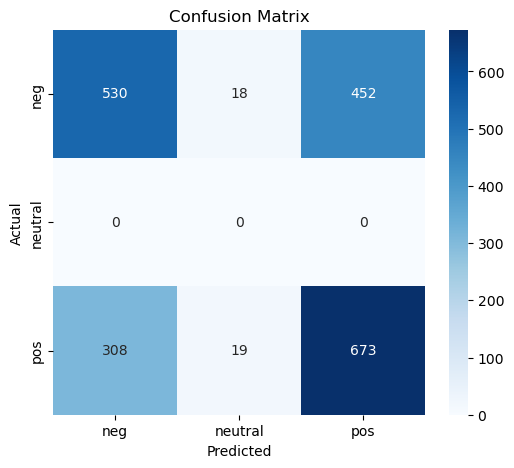

In [211]:
# Extraem les etiquetes reals i les prediccions
real_labels = [category for _, category in reviews]
y_pred = [analyze_review_sentiment(review, ["a"]) for review in [doc[0] for doc in documents]]

print("Adjectives Performance:")
print(classification_report(real_labels, y_pred, zero_division=0))

cm = confusion_matrix(real_labels, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Adjectives/Adverbs Performance:
              precision    recall  f1-score   support

         neg       0.59      0.57      0.58      1000
     neutral       0.00      0.00      0.00         0
         pos       0.59      0.59      0.59      1000

    accuracy                           0.58      2000
   macro avg       0.39      0.39      0.39      2000
weighted avg       0.59      0.58      0.59      2000



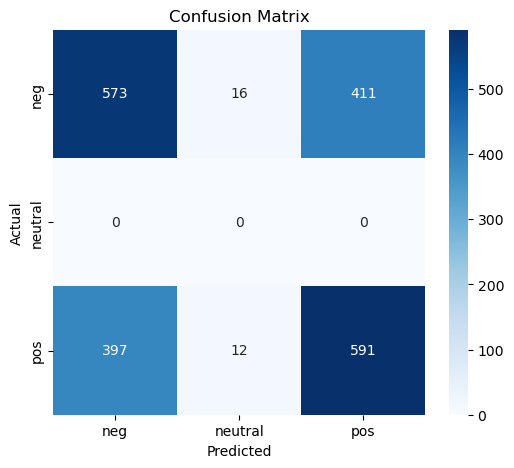

In [212]:
# Extraem les etiquetes reals i les prediccions
real_labels = [category for _, category in reviews]
y_pred = [analyze_review_sentiment(review, accepted = ["n", "a", "r"]) for review in [doc[0] for doc in documents]]

print("Adjectives/Adverbs Performance:")
print(classification_report(real_labels, y_pred, zero_division=0))

cm = confusion_matrix(real_labels, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Adjectives/Adverbs/Verbs Performance:
              precision    recall  f1-score   support

         neg       0.62      0.52      0.57      1000
     neutral       0.00      0.00      0.00         0
         pos       0.59      0.66      0.62      1000

    accuracy                           0.59      2000
   macro avg       0.40      0.40      0.40      2000
weighted avg       0.60      0.59      0.60      2000



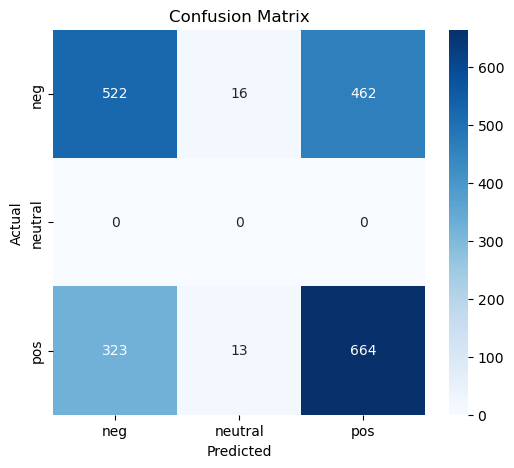

In [214]:
# Extraem les etiquetes reals i les prediccions
real_labels = [category for _, category in reviews]
y_pred = [analyze_review_sentiment(review, accepted = ["n", "a", "r", "v"]) for review in [doc[0] for doc in documents]]

print("Adjectives/Adverbs/Verbs Performance:")
print(classification_report(real_labels, y_pred, zero_division=0))

cm = confusion_matrix(real_labels, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()